<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Red_Bayesiana_Asia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyagrum
import pyagrum as gum
import pyagrum.lib.notebook as gnb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 46.3 MB/s eta 0:00:00


In [2]:
!pip install pyagrum


In [3]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

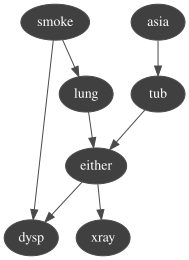

In [4]:
# 1. Crear la estructura de la Red Bayesiana
asia = gum.BayesNet("Asia")

# Crear nodos
asia.add(gum.LabelizedVariable("asia","Viaje a Asia",2))# 0 = No, 1 = Sí
asia.add(gum.LabelizedVariable("smoke","Fuma",2))
asia.add(gum.LabelizedVariable("tub","Tuberculosis",2))
asia.add(gum.LabelizedVariable("lung","Cáncer de pulmón",2))
asia.add(gum.LabelizedVariable("either","Tuberculosis o Cáncer",2))
asia.add(gum.LabelizedVariable("xray","Radiografía positiva",2))
asia.add(gum.LabelizedVariable("dysp","Disnea",2))

# Enlaces (estructura original del modelo Asia)
asia.addArc("asia","tub")
asia.addArc("smoke","lung")
asia.addArc("tub","either")
asia.addArc("lung","either")
asia.addArc("either","xray")
asia.addArc("either","dysp")
asia.addArc("smoke","dysp")

gnb.showBN(asia)

In [5]:
# 2. Definir las Tablas de Probabilidad (CPT)
asia.cpt("asia").fillWith([0.99,0.01])
asia.cpt("smoke").fillWith([0.5,0.5])

asia.cpt("tub")[:] = [ [0.99,0.01],   # asia = No
                       [0.95,0.05] ]  # asia = Sí

asia.cpt("lung")[:] = [ [0.99,0.01],  # smoke = No
                        [0.90,0.10] ] # smoke = Sí

asia.cpt("either")[{'tub':0,'lung':0}] = [1,0]
asia.cpt("either")[{'tub':1,'lung':0}] = [0,1]
asia.cpt("either")[{'tub':0,'lung':1}] = [0,1]
asia.cpt("either")[{'tub':1,'lung':1}] = [0,1]

asia.cpt("xray")[:] = [ [0.95,0.05],   # either = No
                        [0.02,0.98] ]  # either = Sí

asia.cpt("dysp")[{'either':0,'smoke':0}] = [0.9,0.1]
asia.cpt("dysp")[{'either':0,'smoke':1}] = [0.7,0.3]
asia.cpt("dysp")[{'either':1,'smoke':0}] = [0.4,0.6]
asia.cpt("dysp")[{'either':1,'smoke':1}] = [0.3,0.7]

display(asia.cpt("asia"), asia.cpt("smoke"), asia.cpt("tub"),
               asia.cpt("lung"), asia.cpt("either"),asia.cpt("xray"),
               asia.cpt("dysp"))

(pyagrum.Tensor@0x1e4a4210) 
  asia             |
0        |1        |
---------|---------|
 0.9900  | 0.0100  |

(pyagrum.Tensor@0x1e6d0210) 
  smoke            |
0        |1        |
---------|---------|
 0.5000  | 0.5000  |

(pyagrum.Tensor@0x1e711340) 
      ||  tub              |
asia  ||0        |1        |
------||---------|---------|
0     || 0.9900  | 0.0100  |
1     || 0.9500  | 0.0500  |

(pyagrum.Tensor@0x1dff9720) 
      ||  lung             |
smoke ||0        |1        |
------||---------|---------|
0     || 0.9900  | 0.0100  |
1     || 0.9000  | 0.1000  |

(pyagrum.Tensor@0x1e4120c0) 
             ||  either           |
tub   |lung  ||0        |1        |
------|------||---------|---------|
0     |0     || 1.0000  | 0.0000  |
1     |0     || 0.0000  | 1.0000  |
0     |1     || 0.0000  | 1.0000  |
1     |1     || 0.0000  | 1.0000  |

(pyagrum.Tensor@0x1e5d0af0) 
      ||  xray             |
either||0        |1        |
------||---------|---------|
0     || 0.9500  | 0.0500  |
1     || 0.0200  | 0.9800  |

(pyagrum.Tensor@0x1e342780) 
             ||  dysp             |
either|smoke ||0        |1        |
------|------||---------|---------|
0     |0     || 0.9000  | 0.1000  |
1     |0     || 0.4000  | 0.6000  |
0     |1     || 0.7000  | 0.3000  |
1     |1     || 0.3000  | 0.7000  |

In [6]:
# 3. Inferencia con Variable Elimination

ie = gum.LazyPropagation(asia)

In [7]:
# Ejemplo: Paciente con disnea y fumador
ie.setEvidence({"dysp":1, "smoke":1})
posterior = ie.posterior("either")

print("Probabilidad de Tuberculosis o Cáncer dado que fuma y tiene disnea:")
posterior

Probabilidad de Tuberculosis o Cáncer dado que fuma y tiene disnea:


(pyagrum.Tensor@0x1dc626c0) 
  either           |
0        |1        |
---------|---------|
 0.7773  | 0.2227  |

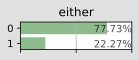

In [8]:
gnb.showProba(posterior)

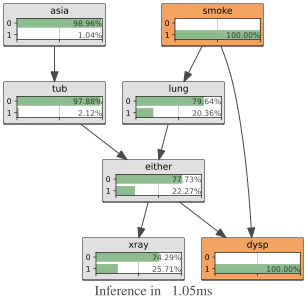

In [9]:
# 4. Mostrar toda la inferencia
gnb.showInference(asia,evs={"dysp":1, "smoke":1})

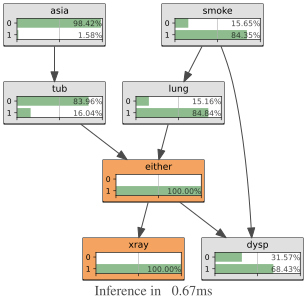

In [10]:
gnb.showInference(asia,evs={"either":1, "xray":1})

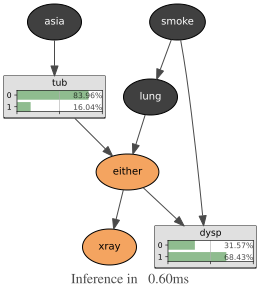

In [13]:
gnb.showInference(asia,evs={'either':1,'xray':1},targets={'dysp','tub'})